# 一月相似日赋权：处境能否改善情景分布？

目标是在问题二 0:00 可知信息下，为历史完整日分配高斯核权重，并决定是否值得替代等权。
只读取附件二 2025 年一月。为遵守不滚动扩充，固定 1 月 4–23 日为候选池、1 月 24–31 日为调参窗口。
预先提出周末、前三日光伏水平、时间距离、昨日光伏、前三日光伏波动与趋势、前三日负载水平七个候选。
季节月份位置作为结构性先验保留，但一月不能验证它。

可复用逻辑按任务要求存放在同目录 `features.py`、`kernel.py`、`validate.py`；本 notebook 只组织分析。
固定 h=1 的逐步消融要求平均 ES 改善超过 0.5%，且至少 5/8 日改善；总计最多四个语义特征。
之后三轮细化带宽，只按平均 ES 选择。最终平均 ES 改善超过 3% 才采纳核加权。

## 分析 1：确认我们实际拥有怎样的历史

先只读一月并核对矩阵完整性。近三日特征需要三个完整历史日，因此最早可用情景为 1 月 4 日。
描述性统计也只针对固定参考池，不能把验证日纳入标准化。净负荷保留整日 144 个功率坐标，用来计算分布的完整 ES。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Image
from features import load_january, FEATURE_DESCRIPTIONS
from validate import (SOURCE, HISTORY, VALIDATION, Experiment, run_ablation,
                      search_bandwidth, save_results, verify_reproducibility, OUTPUT, ASSETS)

load, pv = load_january(SOURCE)
experiment = Experiment(load, pv)
print('Source shapes:', load.shape, pv.shape)
print('Source date range:', load.index.min().date(), load.index.max().date())
print('Missing source values:', int(load.isna().sum().sum() + pv.isna().sum().sum()))
print('Reference / validation days:', len(HISTORY), len(VALIDATION))
print('Incomplete three-day warm-up rows:', int(experiment.features.pv_mean_3d.isna().sum()))
display(experiment.features.loc[HISTORY, ['weekend', 'pv_mean_3d', 'calendar_day', 'load_mean_3d']].agg(['min', 'mean', 'max']))
print('Season unique contexts:', experiment.features[['season_sin', 'season_cos']].drop_duplicates().values.tolist())
print('Equal-weight mean ES:', experiment.scores([], float('inf')).mean())

Source shapes: (31, 144) (31, 144)
Source date range: 2025-01-01 2025-01-31
Missing source values: 0
Reference / validation days: 20 8
Incomplete three-day warm-up rows: 3


,weekend,pv_mean_3d,calendar_day,load_mean_3d
min,0.0,35467.145644,3.0,96098.326639
mean,0.3,37064.309555,12.5,113244.891828
max,1.0,39517.884994,22.0,127142.757033


Season unique contexts: [[0.0, 1.0]]
Equal-weight mean ES: 8411.467321565884


一月两张表均为 **31×144**，没有缺失值。三日滞后仅前 **3** 日缺失，正好支持 **20** 个固定情景与 **8** 个验证日。
参考池前三日光伏均值的范围为 **35,467.15–39,517.88 kWh**，前三日负载均值范围为 **96,098.33–127,142.76 kWh**。
月份处境只有 **(0,1)** 一种，因此季节位置在本实验不产生权重差异。等权平均 ES 为 **8,411.467322 kW**。
这些数字确定了接下来的比较基准；是否为周末、近期光伏及负载水平能否利用历史差异，还必须逐个加入检验。

## 分析 2：哪些 0:00 处境真正改善 ES？

按事先列出的顺序逐个加入特征，固定 h=1。只有平均 ES 改善超过 0.5%，且至少 5/8 日改善才接受。
随后逐个删除最终组合中的季内特征作条件检验，防止后来加入的特征使早先的贡献消失。
季节是任务要求的先验例外，它的零贡献也必须如实记录。

In [2]:
groups, ablation, ablation_daily = run_ablation(experiment)
display(ablation[['stage', 'feature', 'mean_es_before', 'mean_es_after',
                  'relative_improvement_pct', 'improved_days', 'accepted', 'reason']])
print('Selected feature groups:', groups)
print('Fixed-h selected mean ES:', experiment.scores(groups, 1.0).mean())

,stage,feature,mean_es_before,mean_es_after,relative_improvement_pct,improved_days,accepted,reason
0,structural,season,8411.467322,8411.467322,0.000000,0,False,required_prior_not_identifiable_in_january
1,forward,weekend,8411.467322,8662.727328,-2.987113,5,False,insufficient_mean_gain_or_daily_stability
2,forward,pv_mean_3d,8411.467322,10023.654256,-19.166536,3,False,insufficient_mean_gain_or_daily_stability
3,forward,recency,8411.467322,9123.138888,-8.460730,5,False,insufficient_mean_gain_or_daily_stability
4,forward,pv_lag_1d,8411.467322,9569.264630,-13.764511,5,False,insufficient_mean_gain_or_daily_stability
5,forward,pv_std_3d,8411.467322,10329.619199,-22.804010,4,False,insufficient_mean_gain_or_daily_stability
6,forward,pv_trend_3d,8411.467322,8855.626291,-5.280398,4,False,insufficient_mean_gain_or_daily_stability
7,forward,load_mean_3d,8411.467322,7756.598642,7.785427,5,True,pass
8,conditional_1,load_mean_3d,8411.467322,7756.598642,7.785427,5,True,pass


Selected feature groups: ['season', 'load_mean_3d']
Fixed-h selected mean ES: 7756.598641657993


固定 h=1 时，周末和时间距离虽有 **5/8** 日改善，但平均 ES 分别恶化 **2.987%** 和 **8.461%**；不能仅凭改善天数纳入。
前三日光伏均值、昨日光伏、前三日光伏波动、趋势的平均 ES 分别恶化 **19.167%、13.765%、22.804%、5.280%**，均不纳入。
**前三日负载均值**将平均 ES 从 **8,411.467322** 降至 **7,756.598642 kW**，改善 **7.785%**，有 **5/8** 日改善，并通过条件删除检查。
因此固定组合为 **季节位置先验 + 前三日负载均值**，共两个语义特征、三个数值坐标。接下来只调带宽，不能借机重新挑选特征。

## 分析 3：带宽能否让有效的处境信息更有用？

高斯核带宽控制权重集中程度。使用完整 ES，而非单独的目标距离，比较 25 点粗网格并在内部最佳点周围细化三轮。
如果最优值位于边缘则扩展搜索；同时记录等权极限。K_eff 只解释情景集中程度，不参与选带宽。
对选定组合生成逐日配对结果并执行未来数据扰动测试，以区别真实改善与数据泄漏。

Chosen bandwidth:

 0.8509591315907177 status: interior_optimum


,candidates,min_h,max_h,best_mean_es
round,,,,
uniform_limit,1,inf,inf,8411.467322
coarse_0,25,0.050000,20.000000,7740.509168
fine_1,17,0.606962,1.000000,7733.036512
fine_2,17,0.829250,0.882654,7733.010758
fine_3,17,0.848887,0.855535,7733.008565


,date,es_equal,es_kernel,relative_improvement_pct,k_eff_kernel,k_eff_equal,weight_sum,history_size
0,2025-01-24,16156.628527,14496.150273,10.277381,12.344078,20,1.0,20
1,2025-01-25,17179.303374,14434.822469,15.975508,15.667112,20,1.0,20
2,2025-01-26,3050.960252,2349.250921,22.999622,9.796077,20,1.0,20
3,2025-01-27,3555.961281,3216.817148,9.537340,9.800577,20,1.0,20
4,2025-01-28,2947.596613,3867.465612,-31.207425,15.634952,20,1.0,20
5,2025-01-29,4188.203894,4536.905734,-8.325809,12.385091,20,1.0,20
6,2025-01-30,3623.550831,4114.417726,-13.546571,12.537795,20,1.0,20
7,2025-01-31,16589.533802,14848.238634,10.496348,12.478919,20,1.0,20


Mean ES equal / kernel: 8411.467321565884 7733.008564689771
Relative improvement (%): 8.065878769291947
Mean / min / max K_eff: 12.580574992193483 9.796076802354914 15.667111956037322
Adopted method: kernel
Smoke test passes: 8


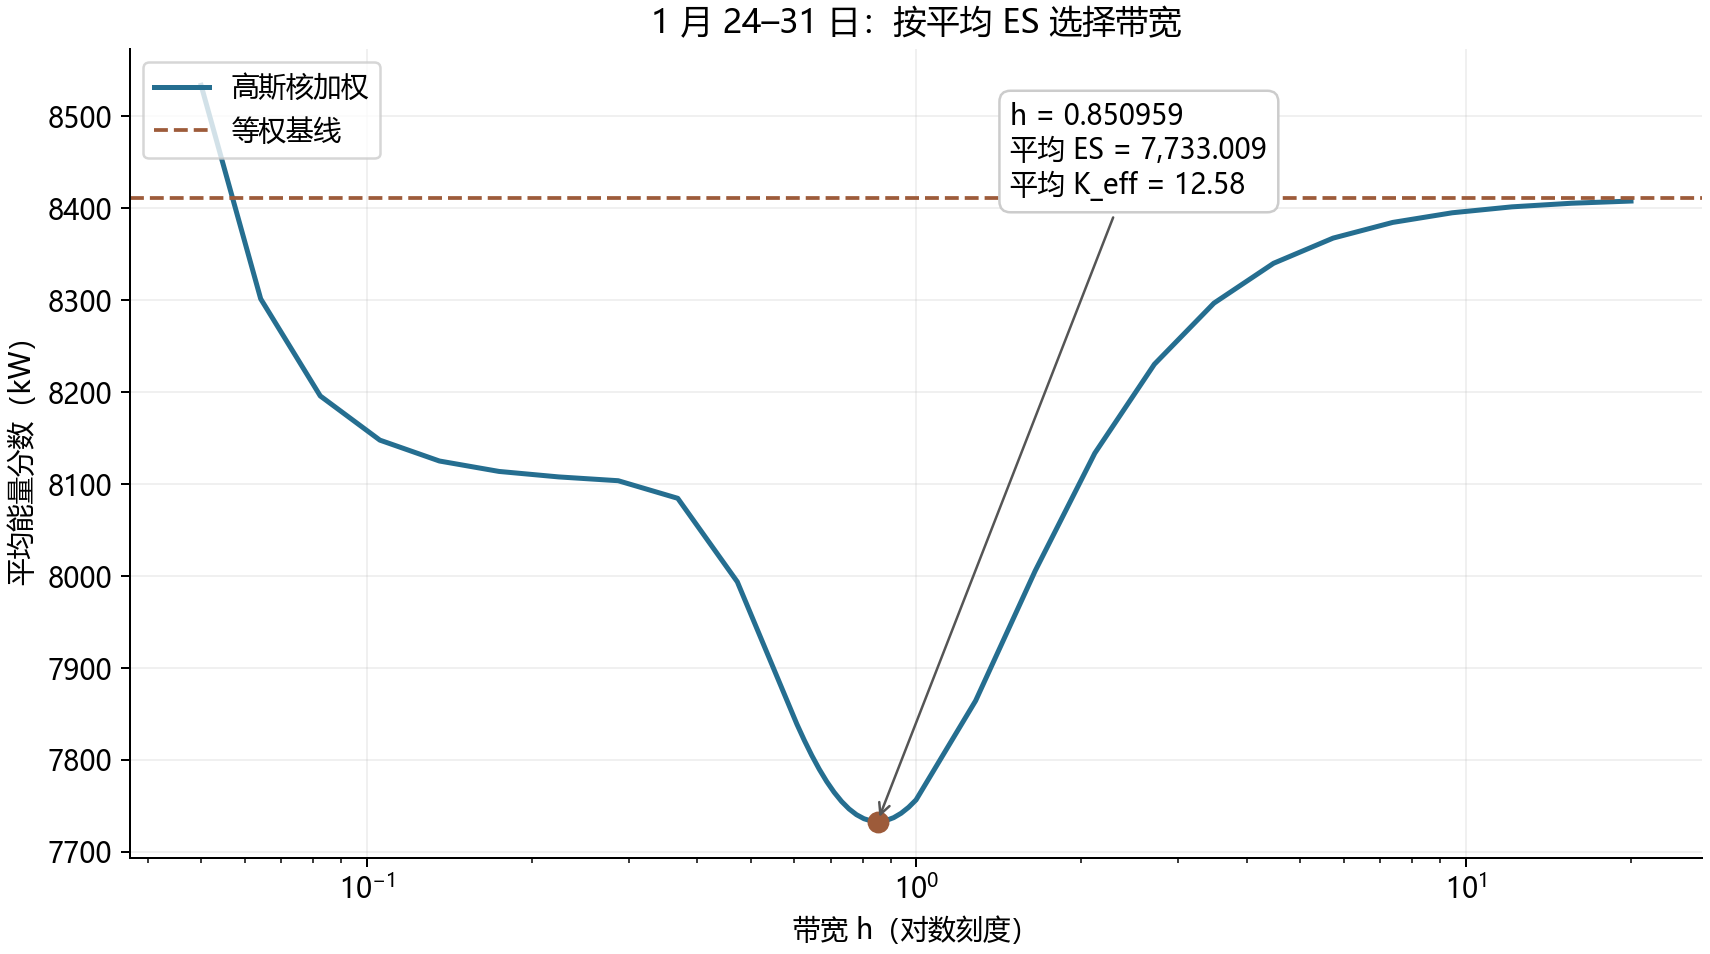

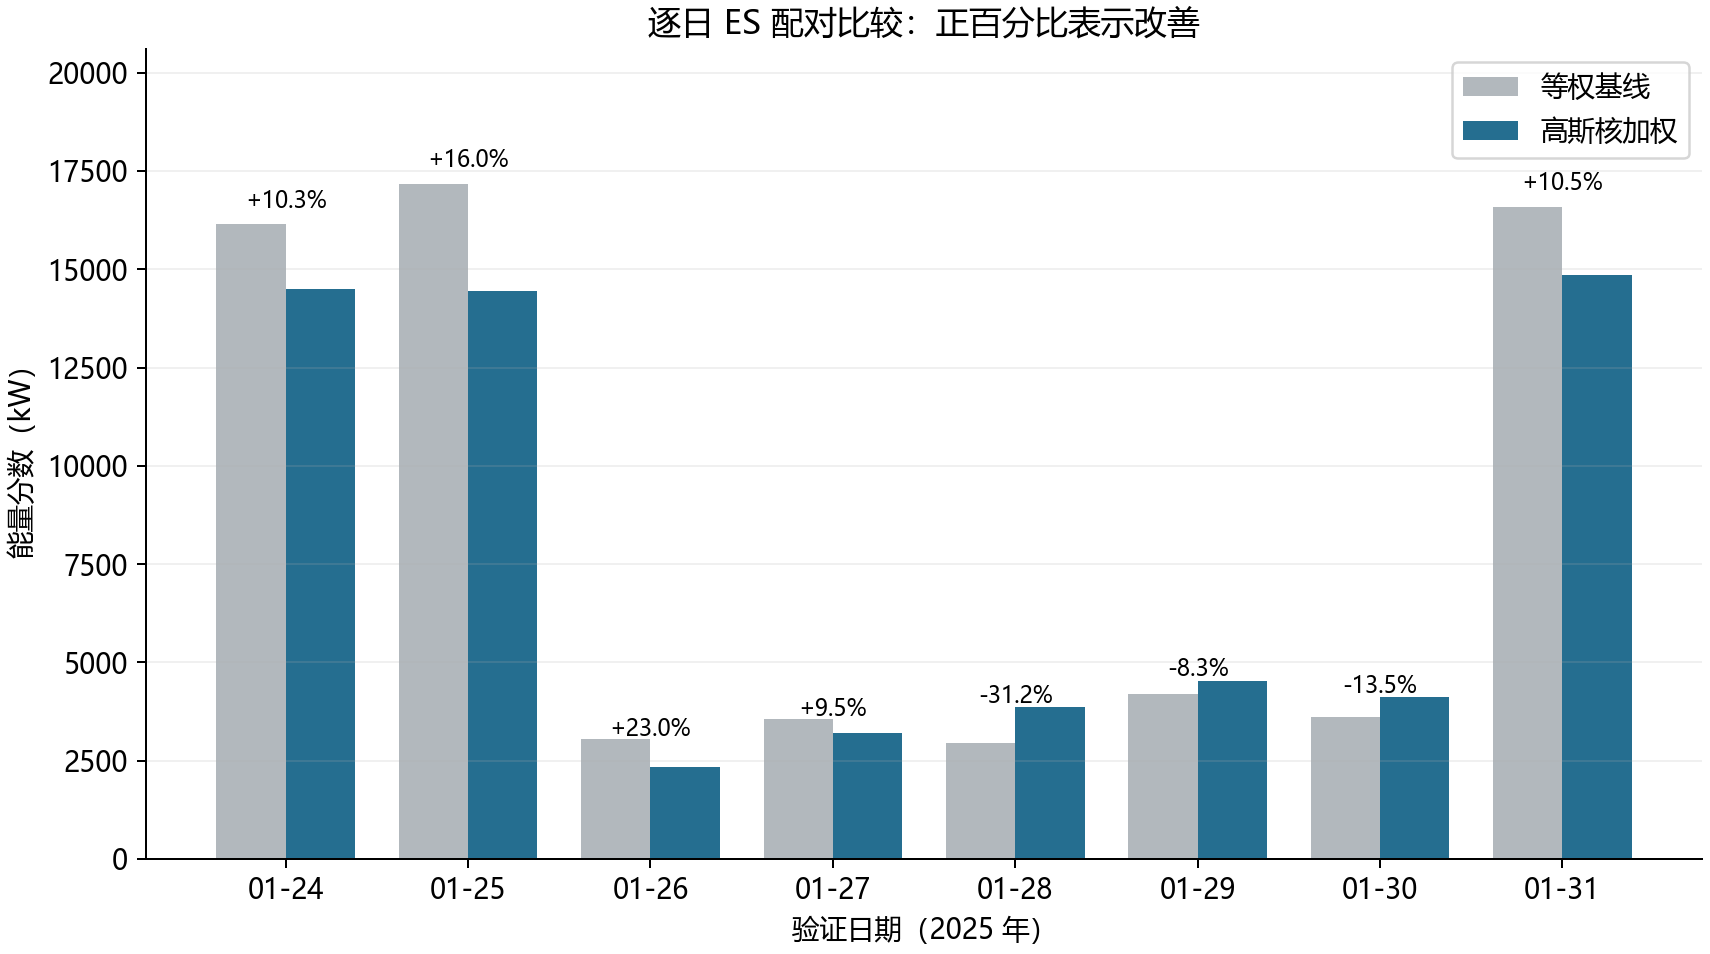

In [3]:
h, search, search_status = search_bandwidth(experiment, groups)
print('Chosen bandwidth:', h, 'status:', search_status)
display(search.groupby('round', sort=False).agg(candidates=('h','size'), min_h=('h','min'), max_h=('h','max'), best_mean_es=('mean_es','min')))
config, comparison = save_results(experiment, groups, h, search_status, ablation, ablation_daily, search)
display(comparison)
print('Mean ES equal / kernel:', comparison.es_equal.mean(), comparison.es_kernel.mean())
print('Relative improvement (%):', config['mean_es_improvement_pct'])
print('Mean / min / max K_eff:', comparison.k_eff_kernel.mean(), comparison.k_eff_kernel.min(), comparison.k_eff_kernel.max())
print('Adopted method:', config['adopted_method'])
print('Smoke test passes:', int(pd.read_csv(OUTPUT / 'smoke_tests.csv').passed.sum()))
display(Image(filename=str(ASSETS / 'bandwidth_curve.png')))
display(Image(filename=str(ASSETS / 'paired_es.png')))

粗搜及三轮细搜将带宽确定为 **h=0.8509591316**，最优点在搜索区间内部。平均 ES 为 **7,733.008565 kW**，相对等权的 **8,411.467322 kW** 改善 **8.0659%**，超过事先规定的 3% 门槛。
核在 **5/8** 日改善；**1 月 28–30 日**分别恶化 **31.207%、8.326%、13.547%**，不可描述为每天有效。
有效情景数均值 **12.5806**，范围 **9.7961–15.6671**，说明核保留了多日分布支持。
未来扰动检查 **8/8** 日通过。季节对本次一月距离贡献为零，结果支持的是前三日负载处境在本调参窗口内的帮助。

这八天同时承担特征与带宽选择，不能当作独立样本外证据。最终规则最早于 **2 月 1 日**可用；给定规则的处境因果性不意味着规则选择未使用一月验证标签。

## 分析 4：从干净环境重跑，是否能得到同一结论？

权重归一化不足以排除泄漏，因此同时检查未来扰动下的处境、历史曲线、冻结标尺和全部测试权重完全不变。
此外，命令行脚本已在新进程的空目录，以及只安装 requirements.txt 的新建隔离 venv 内复跑。
这里读取实际核验记录，而不是把“可以复现”作为未经执行的承诺。评分始终使用另行保存的原始验证真值。

In [4]:
import json
smoke = pd.read_csv(OUTPUT / 'smoke_tests.csv')
repeat = json.loads((OUTPUT / 'reproducibility.json').read_text(encoding='utf-8'))
clean = json.loads((OUTPUT / 'clean_environment.json').read_text(encoding='utf-8'))
print('Smoke passed days:', int(smoke.passed.sum()), '/', len(smoke))
print('Rule/bandwidth pairs per day:', int(smoke.checked_rule_bandwidth_pairs.iloc[0]))
print('Maximum weight difference after future mutation:', smoke.max_absolute_weight_change.max())
print('Fresh process artifact hashes identical:', repeat['passed'], len(repeat['files']))
print('Clean venv artifact hashes identical:', clean['passed'], len(clean['files']))
print('Clean environment details:', clean['environment'])

Smoke passed days: 8 / 8
Rule/bandwidth pairs per day: 77
Maximum weight difference after future mutation: 0
Fresh process artifact hashes identical: True 12
Clean venv artifact hashes identical: True 12
Clean environment details: {'python': '3.13.11', 'is_venv': True, 'user_site_enabled': False, 'packages': {'numpy': '2.4.4', 'pandas': '3.0.2', 'openpyxl': '3.1.5', 'matplotlib': '3.10.8', 'pillow': '12.3.0'}}


**8/8 日**因果检查通过，每日覆盖 **77** 种特征/带宽组合，未来扰动后的最大权重差为 **0**。
空目录独立进程与新建隔离 venv 的 **12 个数值、参数、报告和图像文件**均与原结果 SHA-256 完全一致。
隔离环境为 **Python 3.13.11**，用户 site-packages 未启用，依赖为交付 requirements.txt 中的版本。
因此从原始一月附件到采纳结论的流程可一键复跑，不依赖此前 notebook 的中间变量或缓存。

## 小结

本实验采纳 **高斯核加权**：经验有效特征为 **前三日负载日总电量均值**，季节月份位置按先验保留，冻结带宽 **h=0.8509591316**。
固定 20 日候选池下，平均 ES 从 **8,411.467322** 降至 **7,733.008565 kW**，改善 **8.0659%**，有效情景数均值 **12.5806**。
周末、近期光伏与时间距离在预设 h=1 的本轮消融中未通过，失败结果照实保留；季节不能由一月消融验证。

后续主模型应直接复用 `frozen_rule.json` 的特征、标尺和 h，不用二月之后数据重调。
本结论只覆盖指定调参窗口；未来若改变候选池，或要评价真实独立样本外收益，需要另外设计实验。此处没有进行 LP 求解或全年回测。
